# Project 1 - Analysis Plots

Projectile motion with and without linear air drag, plus the attacker/defender interception study.

## Part 1: Projectile motion without air drag

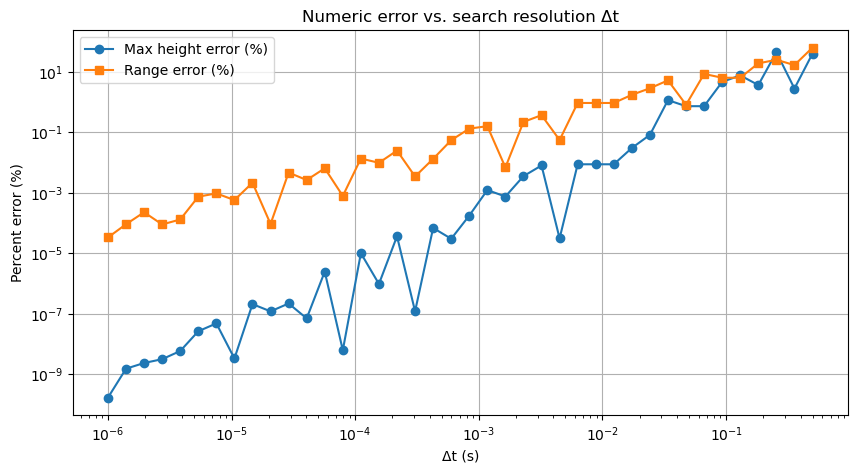

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dt-sweep error data
error_df = pd.read_csv("data/error.csv")

# Plot percent error vs. time-step resolution dt (log-log, as in assignment Fig. 3)
plt.figure(figsize=(10, 5))
plt.plot(error_df["dt"], error_df["error_hmax_pct"], marker='o', label="Max height error (%)")
plt.plot(error_df["dt"], error_df["error_range_pct"], marker='s', label="Range error (%)")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Δt (s)")
plt.ylabel("Percent error (%)")
plt.title("Numeric error vs. search resolution Δt")
plt.legend()
plt.grid()
plt.savefig("data/error_loglog.png", dpi=150, bbox_inches="tight")
plt.show()

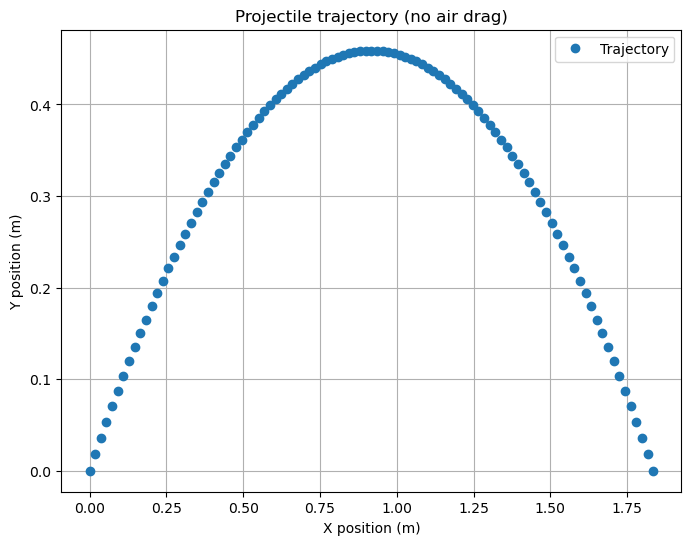

In [2]:
# Load the trajectory data (no drag)
trajectory_df = pd.read_csv("data/trayectoria.csv")

# Sort by x to avoid plotting artifacts
trajectory_df = trajectory_df.sort_values(by="x")

# Plot the projectile trajectory
plt.figure(figsize=(8, 6))
plt.plot(trajectory_df["x"], trajectory_df["y"], marker='o', linestyle='', label="Trajectory")
plt.xlabel("X position (m)")
plt.ylabel("Y position (m)")
plt.title("Projectile trajectory (no air drag)")
plt.legend()
plt.grid()
plt.savefig("data/trajectory_part1.png", dpi=150, bbox_inches="tight")
plt.show()

## Part 2: Projectile motion with air drag

### Trajectory

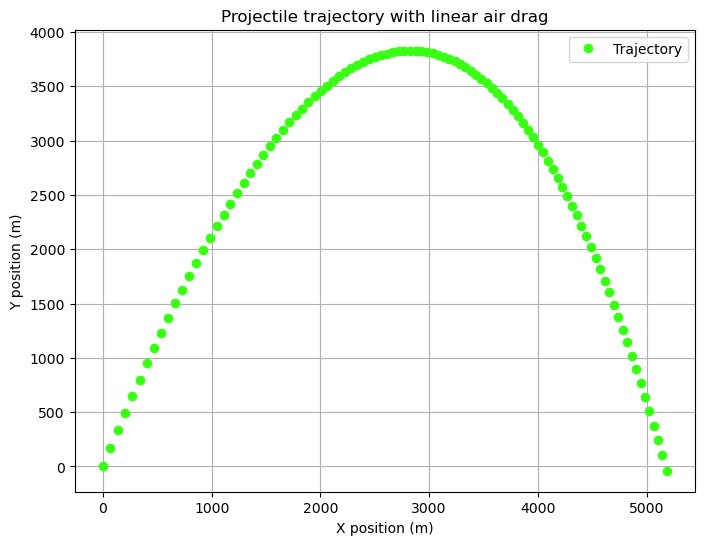

In [3]:
trajectory_df = pd.read_csv("data/trajectory_drag.csv")
trajectory_df = trajectory_df.sort_values(by="X")

# Plot the projectile trajectory
plt.figure(figsize=(8, 6))
plt.plot(trajectory_df["X"], trajectory_df["Y"], marker='o', linestyle='', color='#39FF14', label="Trajectory")
plt.xlabel("X position (m)")
plt.ylabel("Y position (m)")
plt.title("Projectile trajectory with linear air drag")
plt.legend()
plt.grid()
plt.savefig("data/trajectory_part2_drag.png", dpi=150, bbox_inches="tight")
plt.show()

## Part 3: Attacker/defender interception results

For each of the 10 attacker configurations `(V1, theta1)` given in the assignment, `part3_interception.cpp` brute-force searches the defender's launch angle `theta2` and firing delay that intercept the attacker's projectile (within 1 m) as far from the base (x = 5250 m) as possible.

In [4]:
interception_df = pd.read_csv("data/interception_results.csv")
interception_df

,V1,theta1_deg,theta2_deg,delay_s,distance_from_base_m
0,324.0,68.0,69.0,8.28,1463.9451
1,300.0,63.0,63.0,0.00,2000.5000
2,400.0,10.0,13.0,0.60,1428.1265
3,480.0,7.0,11.0,0.36,1173.5985
4,500.0,80.0,78.0,43.48,558.6985
5,250.0,45.0,36.0,1.48,2383.0853
6,1200.0,87.0,60.0,177.32,48.9773
7,270.0,30.0,26.0,3.72,1826.3157
8,890.0,2.0,0.0,0.00,-1.0000
9,3000.0,89.0,81.0,359.96,116.2065


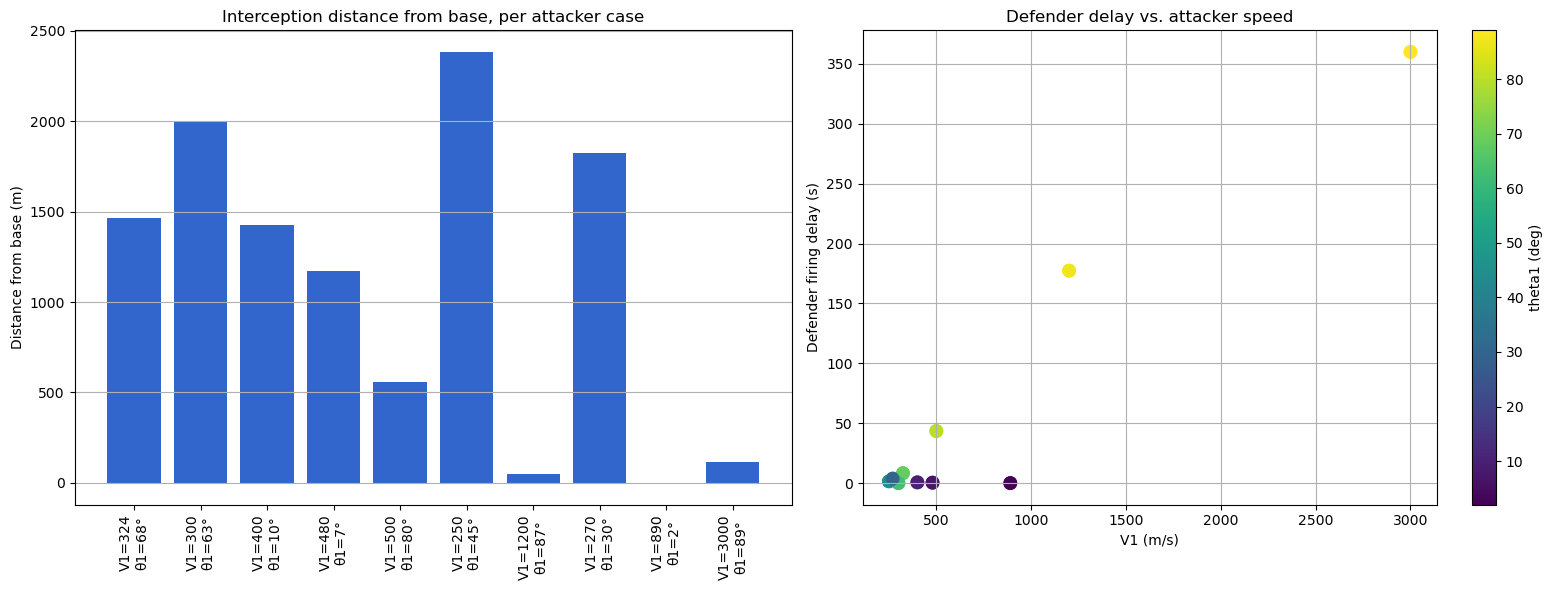

In [5]:
labels = [f"V1={row.V1:.0f}\nθ1={row.theta1_deg:.0f}°" for row in interception_df.itertuples()]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(labels, interception_df["distance_from_base_m"], color='#3366cc')
axes[0].set_ylabel("Distance from base (m)")
axes[0].set_title("Interception distance from base, per attacker case")
axes[0].tick_params(axis='x', rotation=90)
axes[0].grid(axis='y')

axes[1].scatter(interception_df["V1"], interception_df["delay_s"], c=interception_df["theta1_deg"], cmap='viridis', s=80)
sc = axes[1].scatter(interception_df["V1"], interception_df["delay_s"], c=interception_df["theta1_deg"], cmap='viridis', s=80)
cbar = fig.colorbar(sc, ax=axes[1])
cbar.set_label("theta1 (deg)")
axes[1].set_xlabel("V1 (m/s)")
axes[1].set_ylabel("Defender firing delay (s)")
axes[1].set_title("Defender delay vs. attacker speed")
axes[1].grid()

plt.tight_layout()
plt.savefig("data/interception_summary.png", dpi=150, bbox_inches="tight")
plt.show()